<a href="https://colab.research.google.com/github/singhm8755/7150CEM-Ecommerce-Returns-CLV/blob/main/5_CLV_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
CUSTOMER LIFETIME VALUE (CLV) & BUSINESS IMPACT ANALYSIS

SECTION 1: LOADING DATA AND TRAINED XGBOOST MODEL
----------------------------------------------------------------------

Dataset loaded: 120,000 transactions, 12,000 customers

Loaded artefacts:
 - XGBoost model
 - Feature scaler
 - Label encoders for categorical variables

SECTION 2: PREPARING FEATURES & SCORING TRANSACTIONS
----------------------------------------------------------------------

Sample of predicted return probabilities:
   transaction_id  customer_id  pred_return_prob
0           93666          567          0.576690
1           68309         8327          0.341741
2          106907         7450          0.586512
3           87602         7738          0.724056
4           84892        11180          0.563868

Overall mean predicted return probability: 0.510
Actual return rate in data

/tmp/ipykernel_449/922233739.py:204: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=segment_summary.sort_values('mean_clv', ascending=False),


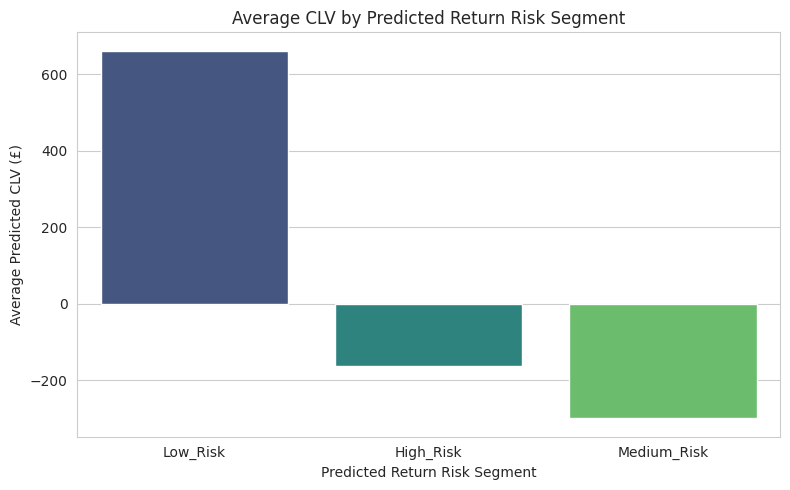

Saved: 12_clv_by_risk_segment.png



/tmp/ipykernel_449/922233739.py:218: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=segment_summary.sort_values('customers', ascending=False),


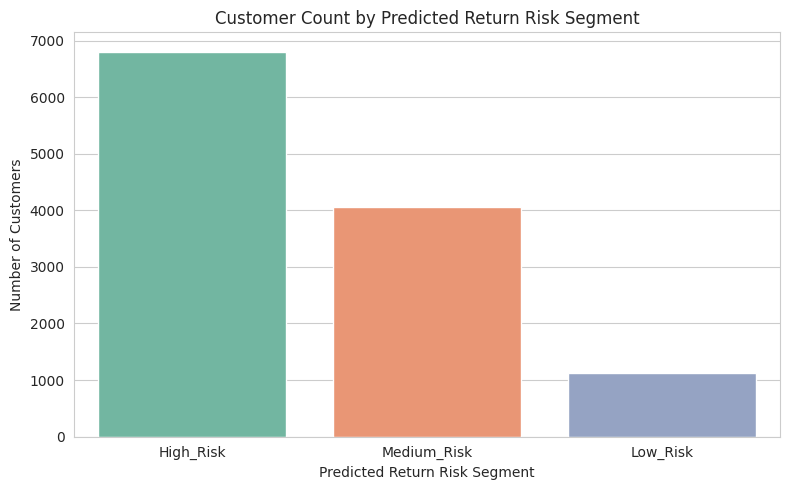

Saved: 13_customers_by_risk_segment.png

SECTION 6: BUSINESS IMPACT SCENARIO
----------------------------------------------------------------------

Baseline portfolio CLV: £-1,577,700.54
Policy   portfolio CLV: £-1,083,108.94
Change in CLV:          £494,591.60

Baseline expected return cost: £7,862,848.26
Policy   expected return cost: £7,318,797.50
Change in return cost:         £-544,050.76

Average per-customer impact by risk segment:
  risk_segment  baseline_clv  policy_clv  baseline_cost  policy_cost  \
0    High_Risk   -162.579589  -89.909651     399.684685   319.747753   
1     Low_Risk    662.247822  662.247822    1003.367507  1003.367507   
2  Medium_Risk   -299.606346 -299.606346     986.422959   986.422959   

   customers  clv_change  cost_change  
0       6806   72.669939   -79.936932  
1       1128    0.000000     0.000000  
2       4066    0.000000     0.000000  



/tmp/ipykernel_449/922233739.py:297: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=impact_by_segment, x='risk_segment', y='clv_change', palette='coolwarm')


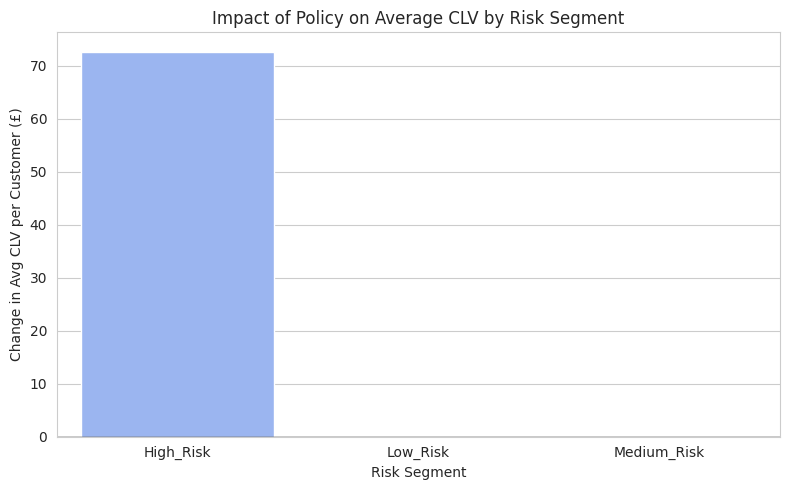

Saved: 14_policy_impact_by_segment.png

SECTION 7: SAVING CUSTOMER-LEVEL DATA
----------------------------------------------------------------------

Customer-level CLV and risk scores saved to:
/content/drive/MyDrive/7150CEM_Project/outputs/customer_clv_predictions.csv

CLV & BUSINESS IMPACT ANALYSIS COMPLETE



In [ ]:
# Customer Lifetime Value & Business Impact Analysis
# Notebook: 5_CLV_Impact.ipynb

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
import joblib

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix
)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

drive.mount('/content/drive')

print("=" * 70)
print("CUSTOMER LIFETIME VALUE (CLV) & BUSINESS IMPACT ANALYSIS")
print("=" * 70)
print()

# ============================================================================
# SECTION 1: LOAD DATA AND TRAINED MODEL
# ============================================================================

print("SECTION 1: LOADING DATA AND TRAINED XGBOOST MODEL")
print("-" * 70)
print()

# Load full transaction dataset
df = pd.read_csv('/content/drive/MyDrive/7150CEM_Project/data/synthetic_ecommerce.csv')
print(f"Dataset loaded: {len(df):,} transactions, {df['customer_id'].nunique():,} customers")
print()

# Load trained artefacts from Notebook 4
model_dir = '/content/drive/MyDrive/7150CEM_Project/models'

xgb_model      = joblib.load(f'{model_dir}/xgboost.pkl')
scaler         = joblib.load(f'{model_dir}/scaler.pkl')
label_encoders = joblib.load(f'{model_dir}/label_encoders.pkl')

print("Loaded artefacts:")
print(" - XGBoost model")
print(" - Feature scaler")
print(" - Label encoders for categorical variables")
print()

# ============================================================================
# SECTION 2: PREPARE FEATURES & SCORE PREDICTED RETURN RISK
# ============================================================================

print("SECTION 2: PREPARING FEATURES & SCORING TRANSACTIONS")
print("-" * 70)
print()

categorical_features = ['product_category', 'payment_method', 'device_type', 'customer_segment']
numeric_features = ['order_value_gbp', 'click_depth', 'time_on_page_seconds',
                   'product_page_visits', 'customer_tenure_days', 'order_frequency_12m']

# Apply the same label encoders as in training
df_scoring = df.copy()

for col in categorical_features:
    le = label_encoders[col]
    df_scoring[col + '_encoded'] = le.transform(df_scoring[col])

feature_cols = [col + '_encoded' for col in categorical_features] + numeric_features
X_all = df_scoring[feature_cols]

# Scale features
X_all_scaled = scaler.transform(X_all)

# Predict probability of return using trained XGBoost
df_scoring['pred_return_prob'] = xgb_model.predict_proba(X_all_scaled)[:, 1]

print("Sample of predicted return probabilities:")
print(df_scoring[['transaction_id', 'customer_id', 'pred_return_prob']].head())
print()

print(f"Overall mean predicted return probability: {df_scoring['pred_return_prob'].mean():.3f}")
print(f"Actual return rate in data: {df_scoring['returned'].mean():.3f}")
print()

# ============================================================================
# SECTION 3: AGGREGATE TO CUSTOMER LEVEL
# ============================================================================

print("SECTION 3: CUSTOMER-LEVEL AGGREGATION")
print("-" * 70)
print()

# Aggregate key metrics per customer
customer_agg = df_scoring.groupby('customer_id').agg(
    n_transactions       = ('transaction_id', 'count'),
    total_revenue_gbp    = ('order_value_gbp', 'sum'),
    avg_order_value_gbp  = ('order_value_gbp', 'mean'),
    actual_return_rate   = ('returned', 'mean'),
    mean_pred_return_prob= ('pred_return_prob', 'mean'),
    max_pred_return_prob = ('pred_return_prob', 'max'),
    tenure_days          = ('customer_tenure_days', 'max'),
    order_frequency_12m  = ('order_frequency_12m', 'max'),
    segment              = ('customer_segment', 'first')
).reset_index()

print("Customer-level sample:")
print(customer_agg.head())
print()

print(f"Customers: {len(customer_agg):,}")
print(f"Average transactions per customer: {customer_agg['n_transactions'].mean():.2f}")
print()

# ============================================================================
# SECTION 4: CLV ASSUMPTIONS & FORMULA
# ============================================================================

print("SECTION 4: DEFINING CLV ASSUMPTIONS")
print("-" * 70)
print()

# Simple CLV model assumptions (you will explain these in the report)
margin_rate   = 0.30   # 30% gross margin
horizon_years = 1      # 1-year CLV horizon
discount_rate = 0.10   # 10% discount rate
return_cost_factor = 1.0  # returning an item "costs" the full order value

print(f"Margin rate:   {margin_rate:.2f}")
print(f"Horizon years: {horizon_years}")
print(f"Discount rate: {discount_rate:.2f}")
print()

# Effective discount factor for 1-year horizon
discount_factor = 1 / (1 + discount_rate) ** horizon_years

# Expected annual gross profit without considering returns
customer_agg['annual_gross_profit'] = (
    customer_agg['order_frequency_12m'] *
    customer_agg['avg_order_value_gbp'] *
    margin_rate
)

# Expected monetary loss from returns using predicted probability
customer_agg['expected_return_cost'] = (
    customer_agg['order_frequency_12m'] *
    customer_agg['avg_order_value_gbp'] *
    customer_agg['mean_pred_return_prob'] *
    return_cost_factor
)

# Final CLV estimate
customer_agg['clv_predicted_gbp'] = (
    (customer_agg['annual_gross_profit'] - customer_agg['expected_return_cost']) *
    discount_factor
)

print("Sample CLV estimates:")
print(customer_agg[['customer_id', 'segment', 'annual_gross_profit',
                    'expected_return_cost', 'clv_predicted_gbp']].head())
print()

print(f"Mean predicted CLV:  £{customer_agg['clv_predicted_gbp'].mean():.2f}")
print(f"Median predicted CLV: £{customer_agg['clv_predicted_gbp'].median():.2f}")
print()

# ============================================================================
# SECTION 5: RISK-BASED CUSTOMER SEGMENTATION
# ============================================================================

print("SECTION 5: SEGMENTATION BY PREDICTED RETURN RISK")
print("-" * 70)
print()

# Define risk bands based on predicted return probability
# You can tweak thresholds later if needed.
def risk_band(p):
    if p < 0.25:
        return 'Low_Risk'
    elif p < 0.50:
        return 'Medium_Risk'
    else:
        return 'High_Risk'

customer_agg['risk_segment'] = customer_agg['mean_pred_return_prob'].apply(risk_band)

segment_summary = customer_agg.groupby('risk_segment').agg(
    customers              = ('customer_id', 'count'),
    mean_pred_return_prob  = ('mean_pred_return_prob', 'mean'),
    mean_actual_return_rate= ('actual_return_rate', 'mean'),
    mean_clv               = ('clv_predicted_gbp', 'mean'),
    total_clv              = ('clv_predicted_gbp', 'sum'),
    mean_orders_12m        = ('order_frequency_12m', 'mean')
).reset_index()

print("Risk segment summary:")
print(segment_summary)
print()

# Bar plot: average CLV by risk segment
plt.figure(figsize=(8, 5))
sns.barplot(data=segment_summary.sort_values('mean_clv', ascending=False),
            x='risk_segment', y='mean_clv', palette='viridis')
plt.ylabel('Average Predicted CLV (£)')
plt.xlabel('Predicted Return Risk Segment')
plt.title('Average CLV by Predicted Return Risk Segment')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/7150CEM_Project/outputs/12_clv_by_risk_segment.png',
            dpi=300, bbox_inches='tight')
plt.show()
print("Saved: 12_clv_by_risk_segment.png")
print()

# Bar plot: customer count per risk segment
plt.figure(figsize=(8, 5))
sns.barplot(data=segment_summary.sort_values('customers', ascending=False),
            x='risk_segment', y='customers', palette='Set2')
plt.ylabel('Number of Customers')
plt.xlabel('Predicted Return Risk Segment')
plt.title('Customer Count by Predicted Return Risk Segment')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/7150CEM_Project/outputs/13_customers_by_risk_segment.png',
            dpi=300, bbox_inches='tight')
plt.show()
print("Saved: 13_customers_by_risk_segment.png")
print()

# ============================================================================
# SECTION 6: BUSINESS SCENARIO – TARGET HIGH-RISK CUSTOMERS
# ============================================================================

print("SECTION 6: BUSINESS IMPACT SCENARIO")
print("-" * 70)
print()

# Example policy: apply stricter checks / interventions for High_Risk customers
# Assume this policy reduces their expected return probability by 20%
policy_effect = 0.20

high_risk = customer_agg['risk_segment'] == 'High_Risk'

customer_agg['mean_pred_return_prob_policy'] = customer_agg['mean_pred_return_prob']
customer_agg.loc[high_risk, 'mean_pred_return_prob_policy'] = (
    customer_agg.loc[high_risk, 'mean_pred_return_prob'] * (1 - policy_effect)
)

# Recompute expected return cost and CLV under policy
customer_agg['expected_return_cost_policy'] = (
    customer_agg['order_frequency_12m'] *
    customer_agg['avg_order_value_gbp'] *
    customer_agg['mean_pred_return_prob_policy'] *
    return_cost_factor
)

customer_agg['clv_policy_gbp'] = (
    (customer_agg['annual_gross_profit'] - customer_agg['expected_return_cost_policy']) *
    discount_factor
)

# Aggregate portfolio-level results
baseline_total_clv = customer_agg['clv_predicted_gbp'].sum()
policy_total_clv   = customer_agg['clv_policy_gbp'].sum()

baseline_return_cost = customer_agg['expected_return_cost'].sum()
policy_return_cost   = customer_agg['expected_return_cost_policy'].sum()

print(f"Baseline portfolio CLV: £{baseline_total_clv:,.2f}")
print(f"Policy   portfolio CLV: £{policy_total_clv:,.2f}")
print(f"Change in CLV:          £{(policy_total_clv - baseline_total_clv):,.2f}")
print()

print(f"Baseline expected return cost: £{baseline_return_cost:,.2f}")
print(f"Policy   expected return cost: £{policy_return_cost:,.2f}")
print(f"Change in return cost:         £{(policy_return_cost - baseline_return_cost):,.2f}")
print()

# Segment-level impact (esp. High_Risk)
impact_by_segment = customer_agg.groupby('risk_segment').agg(
    baseline_clv = ('clv_predicted_gbp', 'mean'),
    policy_clv   = ('clv_policy_gbp', 'mean'),
    baseline_cost= ('expected_return_cost', 'mean'),
    policy_cost  = ('expected_return_cost_policy', 'mean'),
    customers    = ('customer_id', 'count')
).reset_index()

impact_by_segment['clv_change']   = impact_by_segment['policy_clv'] - impact_by_segment['baseline_clv']
impact_by_segment['cost_change']  = impact_by_segment['policy_cost'] - impact_by_segment['baseline_cost']

print("Average per-customer impact by risk segment:")
print(impact_by_segment)
print()

# Plot CLV change by segment
plt.figure(figsize=(8, 5))
sns.barplot(data=impact_by_segment, x='risk_segment', y='clv_change', palette='coolwarm')
plt.axhline(0, color='black', linewidth=1)
plt.ylabel('Change in Avg CLV per Customer (£)')
plt.xlabel('Risk Segment')
plt.title('Impact of Policy on Average CLV by Risk Segment')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/7150CEM_Project/outputs/14_policy_impact_by_segment.png',
            dpi=300, bbox_inches='tight')
plt.show()
print("Saved: 14_policy_impact_by_segment.png")
print()

# ============================================================================
# SECTION 7: SAVE CUSTOMER-LEVEL OUTPUT
# ============================================================================

print("SECTION 7: SAVING CUSTOMER-LEVEL DATA")
print("-" * 70)
print()

output_path = '/content/drive/MyDrive/7150CEM_Project/outputs/customer_clv_predictions.csv'
customer_agg.to_csv(output_path, index=False)

print(f"Customer-level CLV and risk scores saved to:\n{output_path}")
print()

print("=" * 70)
print("CLV & BUSINESS IMPACT ANALYSIS COMPLETE")
print("=" * 70)
print()
